# Base de dades 2019

Aquest notebook utilitza els conjunts de dades del 2019 proporcionats per la competició IPIN. Amb aquests s'ha seguit els següents passos:

1. Anàlisi exploratòria i reducció manual de la dimensionalitat
2. Experiments amb models d'aprenentatge automàtic

In [2]:
# llibreries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import VarianceThreshold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

In [ ]:
# Detectar si s'executa a Google Colab
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# A Colab cal clonar el repositori públic per tenir accés a les dades.
# En local s'assumeix que el notebook s'executa des de l'arrel del repositori clonat.
if IN_COLAB:
    if not os.path.isdir('indoor-location'):
        !git clone https://github.com/nuriacanals3/indoor-location.git
    os.chdir('indoor-location')

In [4]:
# Carregar les dades

# Definir la ruta base de les dades
base_path = './Dades/2019/'

# Train
df_train_rss_2019 = pd.read_csv(os.path.join(base_path, 'ipin2019_trainrss.csv'), header=None)
df_train_fl_2019  = pd.read_csv(os.path.join(base_path, 'ipin2019_trainflr.csv'), header=None)

# Validate
df_val_rss_2019 = pd.read_csv(os.path.join(base_path, 'ipin2019_validrss.csv'), header=None)
df_val_fl_2019  = pd.read_csv(os.path.join(base_path, 'ipin2019_validflr.csv'), header=None)

# Test
df_test_rss_2019 = pd.read_csv(os.path.join(base_path, 'ipin2019_ctestreducedrss.csv'), header=None)
df_test_fl_2019  = pd.read_csv(os.path.join(base_path, 'ipin2019_ctestreducedfloor.csv'), header=None)

## Anàlisi exploratòria i reducció manual de la dimensionalitat
A continuació es fa un anàlisi de les dades i una reducció manual de la dimensionalitat del conjunt d'entrenament utilitzant els següents dataframes:
*   df_train_rss_2019
*   df_train_fl_2019



In [5]:
# Dimensionalitat de les dades
df_train_rss_2019.shape

(3274, 708)

In [ ]:
# Anomenar columnes APs
nous_noms = [f"AP_{i}" for i in range(708)]
df_train_rss_2019.columns = nous_noms
df_val_rss_2019.columns = nous_noms
df_test_rss_2019.columns = nous_noms

# Juntar el dataset de potències amb el de planta
df_train_2019 = pd.concat([df_train_rss_2019, df_train_fl_2019], axis=1)

# Reanomenar la columna objectiu
df_train_2019 = df_train_2019.rename(columns={0: 'Pis'})

df_train_2019.head()

,AP_0,AP_1,AP_2,AP_3,AP_4,AP_5,AP_6,AP_7,AP_8,AP_9,...,AP_699,AP_700,AP_701,AP_702,AP_703,AP_704,AP_705,AP_706,AP_707,Pis
0,-74,-75,-76,-77,-77,-92,-92,100,100,100,...,100,100,100,100,100,100,100,100,100,2
1,-74,-83,100,-85,-88,-86,100,-86,-86,-89,...,100,100,100,100,100,100,100,100,100,2
2,-78,100,-81,-82,-84,-84,-84,100,100,-85,...,100,100,100,100,100,100,100,100,100,2
3,-72,-83,100,-80,-80,100,100,100,100,-89,...,100,100,100,100,100,100,100,100,100,2
4,-76,-79,-78,-76,-77,-86,100,-85,-86,100,...,100,100,100,100,100,100,100,100,100,2


In [ ]:
# Canviar els valors 100 per a NaN per analitzar les dades
df_train_2019 = df_train_2019.replace(100, np.nan)

In [ ]:
# Rang potències
rss_min_global = df_train_2019.drop(columns=['Pis']).min().min()
rss_max_global = df_train_2019.drop(columns=['Pis']).max().max()

print(f"Senyal més feble global: {rss_min_global} dBm")
print(f"Senyal més forta global: {rss_max_global} dBm")

Senyal més feble global: -100.0 dBm
Senyal més forta global: -28.0 dBm


In [ ]:
# Columna objectiu
plantes = df_train_2019['Pis'].unique()

print(f"L'edifici està composat per {len(plantes)} plantes: {plantes.tolist()}")

L'edifici està composat per 3 plantes: [2, 1, 0]


### Pas 1 - Reducció de la dimensionalitat:

Eliminar els punts d'accés (AP) que no reben cap senyal. En aquest cas s'ha passat d'un conjunt amb 708 punts d'accés a un reduït de 681.

In [ ]:
# Eliminar les columnes on tots els valors siguin NaN
df_train_2019_reduced = df_train_2019.dropna(axis=1, how='all')

print(f"Columnes originals: {df_train_2019.shape[1]}")
print(f"Columnes útils: {df_train_2019_reduced.shape[1]}")

Columnes originals: 709
Columnes útils: 682


### Pas 2 - Reducció de la dimensionalitat:

1. Anàlisi dels punts d'accés (APs) amb molt baixa latència.
2. Anàlisi de la freqüència d'aparició dels punts d'accés per planta.
3. Anàlisi de la freqüència de les potències més fortes.
4. Eliminar els APs amb una detecció menor al 5% de registres i un RSS major a -80.


**1. Anàlisi dels APs amb molt baixa latència:**

In [ ]:
# Comptar quants cops apareix NaN a cada columna
aps = df_train_2019_reduced.drop(columns=['Pis'])
comptador_no_senyal = aps.isna().sum() # Índex = nom columna (AP), Valor = comptador

# Calcular el percentatge d'absència de senyal
percentatge_no_senyal = (comptador_no_senyal / len(aps)) * 100

# Unir les dades per visualitzar-les
df_analisi_buits = pd.DataFrame({
    'Num_No_Senyal': comptador_no_senyal,
    'Percentatge_Buits': percentatge_no_senyal
})

# Ordenar descendentment per percentatge de buits
df_analisi_buits = df_analisi_buits.sort_values(by='Percentatge_Buits', ascending=False)

# Mostrar els 20 primers
print("Top 20 punts d'accés Wi-Fi menys utilitzats:")
print(df_analisi_buits.head(20))

Top 20 punts d'accés Wi-Fi menys utilitzats:
        Num_No_Senyal  Percentatge_Buits
AP_680           3273          99.969456
AP_679           3273          99.969456
AP_650           3273          99.969456
AP_651           3273          99.969456
AP_652           3273          99.969456
AP_644           3273          99.969456
AP_646           3273          99.969456
AP_649           3273          99.969456
AP_642           3273          99.969456
AP_639           3273          99.969456
AP_628           3273          99.969456
AP_569           3273          99.969456
AP_607           3273          99.969456
AP_103           3273          99.969456
AP_366           3273          99.969456
AP_368           3273          99.969456
AP_665           3273          99.969456
AP_369           3273          99.969456
AP_435           3273          99.969456
AP_453           3273          99.969456


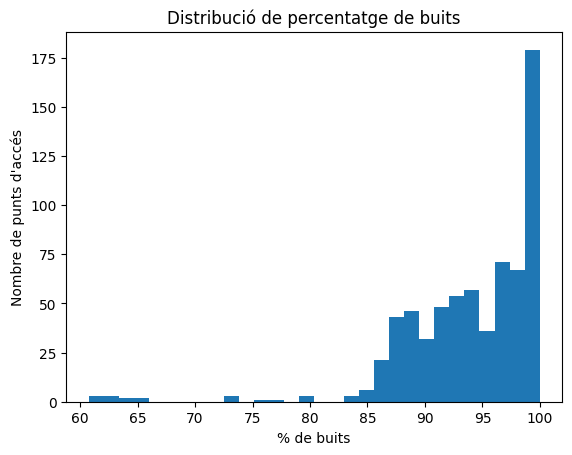

In [ ]:
# Histograma per veure la distribució global
plt.figure()
plt.hist(df_analisi_buits['Percentatge_Buits'], bins=30)
plt.xlabel("% de buits")
plt.ylabel("Nombre de punts d'accés")
plt.title("Distribució de percentatge de buits")
plt.show()


In [ ]:
# Mostrar el total que passen el 95% de buits
punts_mes_95 = df_analisi_buits[df_analisi_buits['Percentatge_Buits'] > 95]
print(f"Punts Wi-Fi amb més del 95% buits: {len(punts_mes_95)} de {aps.shape[1]}")
print(punts_mes_95)

Punts Wi-Fi amb més del 95% buits: 348 de 681
        Num_No_Senyal  Percentatge_Buits
AP_680           3273          99.969456
AP_679           3273          99.969456
AP_650           3273          99.969456
AP_651           3273          99.969456
AP_652           3273          99.969456
...               ...                ...
AP_550           3120          95.296274
AP_43            3118          95.235186
AP_507           3116          95.174099
AP_164           3115          95.143555
AP_526           3111          95.021381

[348 rows x 2 columns]


Aquest anàlisi mostra que existeixen molts punts d'accés on pràcticament tots els seus registres són buits. A continuació s'analitza en profunditat la freqüència de detecció de cada punt d'accés i la potència màxima.

**2. Anàlisi de la freqüència d'aparició dels APs en cada planta:**

Heatmap per veure quantes vegades es detecta cada AP en cada planta.

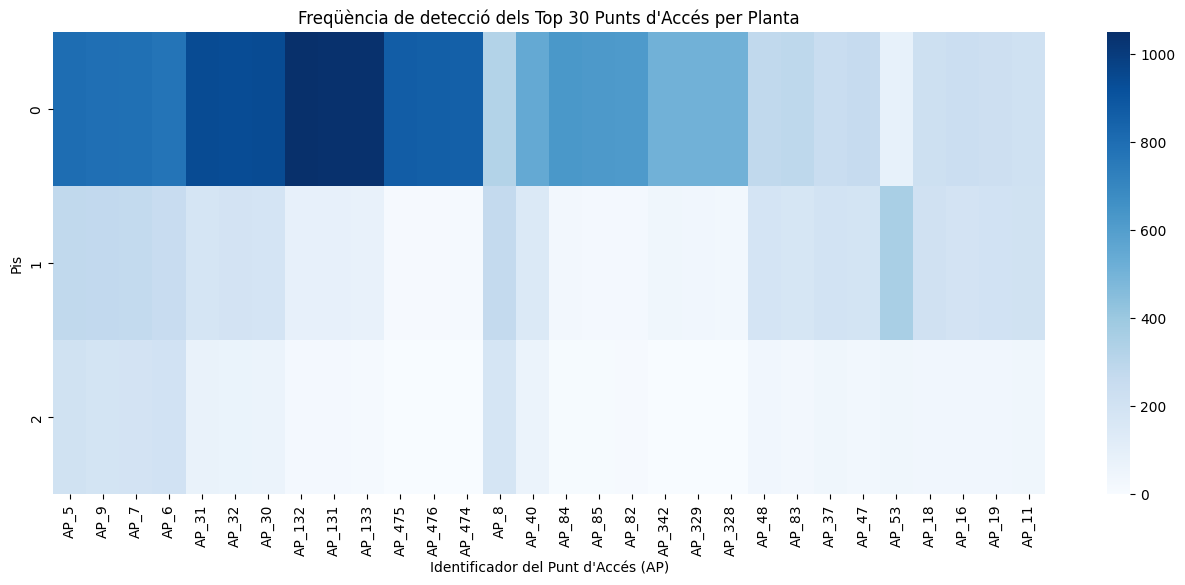

In [ ]:
# Calcular la freqüència: quantes vegades es veu cada AP a cada pis
freq_ap_pis = df_train_2019_reduced.groupby('Pis').count()

# Visualització: filtrar els 30 que més apareixen per veure-ho més clar
top_30_aps = freq_ap_pis.sum().nlargest(30).index

plt.figure(figsize=(16, 6))
sns.heatmap(freq_ap_pis[top_30_aps], cmap='Blues', annot=False)
plt.title('Freqüència de detecció dels Top 30 Punts d\'Accés per Planta')
plt.ylabel('Pis')
plt.xlabel('Identificador del Punt d\'Accés (AP)')
plt.show()



*   **Planta 0:** Gairebé tots els Top 30 APs es detecten amb una freqüència molt alta (> 400 vegades). És molt probable que la majoria de la infraestructura Wi-Fi estigui instal·lada en aquesta planta.
*   **Planta 1:** Els mateixos APs es detecten a la planta 1, però amb molta menys freqüència. Això vol dir que el senyal travessa el sostre.
*   **Planta 2:** També detecta alguns dels APs principals però amb menys freqüència, suggerint que l'edifici no deu ser molt alt.


**3. Anàlisi de la freqüència de les potències més fortes:**

Histograma de freqüències dels valors més potents de cada registre de manera global i per planta.

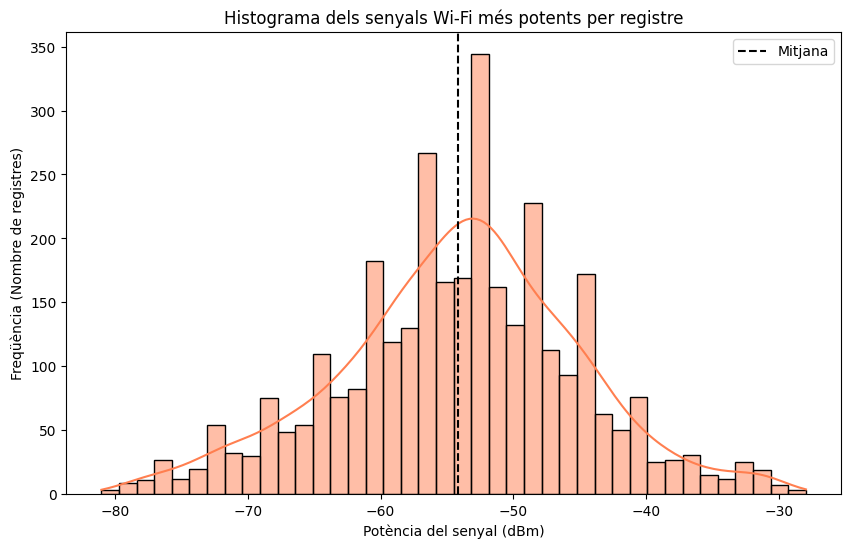

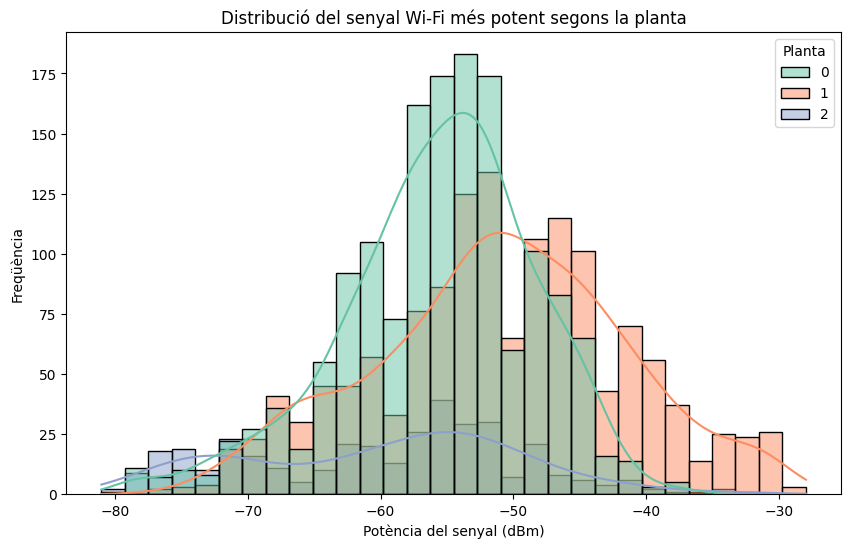

In [ ]:
# Separar la columna objectiu
pisos = df_train_2019_reduced.iloc[:, -1]
senyals = df_train_2019_reduced.iloc[:, :-1]

# Trobar el senyal més potent per a cada registre
valors_mes_potents = senyals.max(axis=1)

# Histograma global
plt.figure(figsize=(10, 6))
sns.histplot(valors_mes_potents, bins=40, color='coral', kde=True)
plt.title('Histograma dels senyals Wi-Fi més potents per registre')
plt.xlabel('Potència del senyal (dBm)')
plt.ylabel('Freqüència (Nombre de registres)')
plt.axvline(valors_mes_potents.mean(), color='black', linestyle='dashed', linewidth=1.5, label='Mitjana')
plt.legend()
plt.show()

# Histograma per pis
df_plot = senyals.copy()
df_plot['Planta'] = pisos
df_plot['max_signal'] = valors_mes_potents

plt.figure(figsize=(10, 6))
sns.histplot(data=df_plot, x='max_signal', hue='Planta', kde=True, bins=30, palette='Set2')
plt.title('Distribució del senyal Wi-Fi més potent segons la planta')
plt.xlabel('Potència del senyal (dBm)')
plt.ylabel('Freqüència')
plt.show()



**4. Eliminar els APs amb una detecció menor al 5% de registres i un RSS major a -80:**

In [ ]:
# Separar variable objectiu
aps = df_train_2019_reduced.iloc[:, :-1]
planta = df_train_2019_reduced.iloc[:, -1]

# Calcular els APs possibles a eliminar
stats_signal = pd.DataFrame({
    "count": aps.count(),
    "max": aps.max()
})

# Llindars
perc_detectats = 0.05
potencia_max = -80

# Identificar els APs a eliminar
aps_eliminar = stats_signal[
    (stats_signal['count'] < len(aps)*perc_detectats) &
    (stats_signal['max'] < potencia_max)
]

# Eliminar i ajuntar la variable planta
aps_reduced  = aps.drop(columns=aps_eliminar.index)
df_train_2019_reduced_2 = pd.concat([aps_reduced, planta], axis=1)

print(f"{len(aps_eliminar)} APs eliminats: {aps_eliminar.index.to_list()} \n {aps_eliminar}")
print(f"Dimensions originals: {df_train_2019_reduced.shape[1]}")
print(f"Dimensions noves: {df_train_2019_reduced_2.shape[1]}")

108 APs eliminats: ['AP_41', 'AP_42', 'AP_98', 'AP_102', 'AP_103', 'AP_104', 'AP_105', 'AP_119', 'AP_120', 'AP_121', 'AP_144', 'AP_247', 'AP_291', 'AP_314', 'AP_317', 'AP_326', 'AP_358', 'AP_359', 'AP_360', 'AP_361', 'AP_366', 'AP_367', 'AP_368', 'AP_369', 'AP_370', 'AP_404', 'AP_413', 'AP_416', 'AP_420', 'AP_421', 'AP_422', 'AP_428', 'AP_435', 'AP_445', 'AP_446', 'AP_447', 'AP_453', 'AP_454', 'AP_460', 'AP_465', 'AP_466', 'AP_467', 'AP_468', 'AP_469', 'AP_492', 'AP_493', 'AP_494', 'AP_500', 'AP_501', 'AP_504', 'AP_505', 'AP_510', 'AP_511', 'AP_514', 'AP_518', 'AP_539', 'AP_552', 'AP_553', 'AP_554', 'AP_555', 'AP_556', 'AP_557', 'AP_560', 'AP_567', 'AP_569', 'AP_570', 'AP_577', 'AP_579', 'AP_580', 'AP_581', 'AP_582', 'AP_596', 'AP_600', 'AP_601', 'AP_607', 'AP_612', 'AP_618', 'AP_619', 'AP_621', 'AP_622', 'AP_623', 'AP_624', 'AP_625', 'AP_626', 'AP_627', 'AP_628', 'AP_630', 'AP_637', 'AP_638', 'AP_639', 'AP_640', 'AP_641', 'AP_642', 'AP_643', 'AP_644', 'AP_646', 'AP_647', 'AP_649', 'AP

En aquest pas s'ha eliminat 108 APs, passant de 681 a 573.

### Pas 3 - Reducció de la dimensionalitat:

1. Anàlisi de les correlacions entre APs.
2. Eliminar APs altament correlacionats (Redundància).

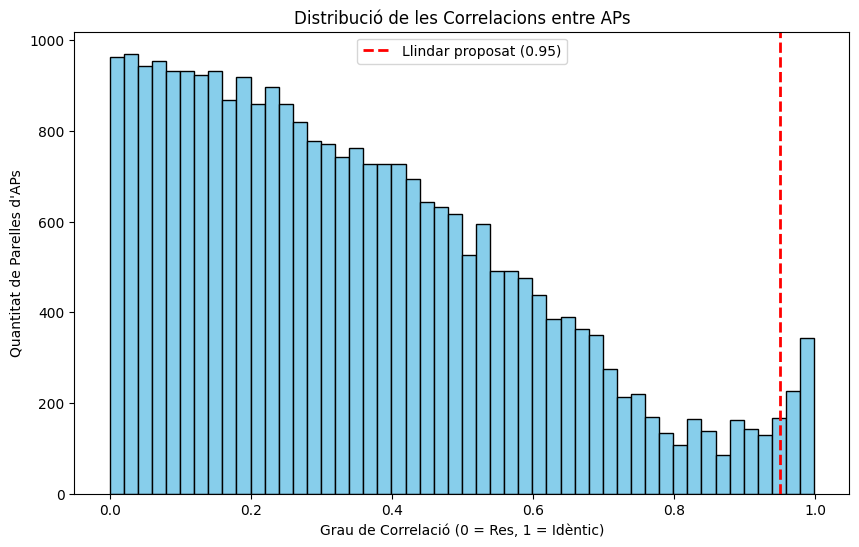

In [ ]:
# Almenys han de tenir 30 mostres compartides per calcular la correlació
minim_mostres_compartides = 30

# Calcular la matriu de correlació
corr_matrix = df_train_2019_reduced_2.drop(columns=['Pis']).corr(min_periods=minim_mostres_compartides).abs()

# Seleccionar el triangle superior de la matriu per evaluar només 1 cop cada parella
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Crear histograma
upper_values = upper.stack()
plt.figure(figsize=(10, 6))
plt.hist(upper_values, bins=50, color='skyblue', edgecolor='black')

# Dibuixar una línia vermella on llindar (0.95)
plt.axvline(x=0.95, color='red', linestyle='--', linewidth=2, label='Llindar proposat (0.95)')

plt.title('Distribució de les Correlacions entre APs')
plt.xlabel('Grau de Correlació (0 = Res, 1 = Idèntic)')
plt.ylabel('Quantitat de Parelles d\'APs')
plt.legend()
plt.show()

La majoria de punts d'accés no estan altament correlacionats, és a dir, aporten informació diferent.

In [ ]:
# Definir llindar (si dos APs s'assemble més d'aquest %, s'elimina un)
llindar = 0.95

# Identificar les columnes a eliminar
to_drop = [column for column in upper.columns if any(upper[column] > llindar)]

print(f"Amb un mínim de {minim_mostres_compartides} mostres, s'han detectat {len(to_drop)} APs altament correlacionats (llindar > {llindar})")

# Veure quins APs s'han eliminat
print("Columnes a eliminar:", to_drop)

Amb un mínim de 30 mostres, s'han detectat 237 APs altament correlacionats (llindar > 0.95)
Columnes a eliminar: ['AP_3', 'AP_4', 'AP_6', 'AP_7', 'AP_9', 'AP_12', 'AP_13', 'AP_16', 'AP_17', 'AP_18', 'AP_19', 'AP_20', 'AP_21', 'AP_23', 'AP_24', 'AP_28', 'AP_29', 'AP_31', 'AP_32', 'AP_33', 'AP_34', 'AP_35', 'AP_37', 'AP_38', 'AP_39', 'AP_46', 'AP_47', 'AP_48', 'AP_49', 'AP_50', 'AP_51', 'AP_52', 'AP_53', 'AP_54', 'AP_55', 'AP_57', 'AP_59', 'AP_62', 'AP_64', 'AP_66', 'AP_67', 'AP_68', 'AP_69', 'AP_75', 'AP_77', 'AP_80', 'AP_83', 'AP_84', 'AP_85', 'AP_88', 'AP_91', 'AP_95', 'AP_96', 'AP_97', 'AP_99', 'AP_100', 'AP_101', 'AP_106', 'AP_107', 'AP_108', 'AP_109', 'AP_110', 'AP_113', 'AP_116', 'AP_117', 'AP_124', 'AP_125', 'AP_126', 'AP_127', 'AP_128', 'AP_129', 'AP_130', 'AP_132', 'AP_133', 'AP_134', 'AP_135', 'AP_139', 'AP_140', 'AP_142', 'AP_146', 'AP_147', 'AP_148', 'AP_149', 'AP_150', 'AP_151', 'AP_152', 'AP_154', 'AP_156', 'AP_157', 'AP_158', 'AP_159', 'AP_160', 'AP_161', 'AP_162', 'AP_17

In [ ]:
def visualitzar_totes_les_correlacions(df, matriu_upper, llindar):
    """
    Busca els parells altament correlacionats i en dibuixa un gràfic de dispersió.
    """
    # 1. Trobar quins parells superen el llindar
    parells_corr = matriu_upper.stack()
    parells_alts = parells_corr[parells_corr > llindar]

    if len(parells_alts) == 0:
        print(f"No s'ha trobat cap parell amb una correlació superior a {llindar}.")
        return

    print(f"S'han detectat {len(parells_alts)} parells altament correlacionats. Generant gràfiques...\n")
    print("-" * 50)

    # 2. Iterar sobre cada parell i dibuixar-lo
    for (ap_principal, ap_eliminat), valor in parells_alts.items():
        plt.figure(figsize=(6, 4))

        mostres_ap_princ = df[ap_principal].notna().sum()
        mostres_ap_elim = df[ap_eliminat].notna().sum()

        # Calcular quantes vegades s'han vist junts (cap dels dos és NaN)
        mostres_compartides = df[[ap_principal, ap_eliminat]].dropna().shape[0]

        # Dibuixem els punts amb certa transparència (alpha) per veure on s'acumulen
        plt.scatter(df[ap_principal], df[ap_eliminat], alpha=0.3, color='teal')

        # Estil i etiquetes
        plt.title(f"Correlació: {valor:.4f}\n{ap_principal} (Es manté) vs {ap_eliminat} (S'elimina)")
        plt.xlabel(f"Senyal de {ap_principal}")
        plt.ylabel(f"Senyal de {ap_eliminat}")
        plt.grid(True, linestyle='--', alpha=0.6)

        plt.show()


visualitzar_totes_les_correlacions(df_train_2019_reduced_2, upper, llindar)

Output hidden; open in https://colab.research.google.com to view.

En aquests gràfics, es forma una linia recta ascendent la qual mostra la correlació dels dos punts d'accés. Els dos tenen intensitats similars i creixen i decreixen en els mateixos registres.

In [ ]:
# Eliminar aquests APs redundants
df_train_2019_reduced_3 = df_train_2019_reduced_2.drop(columns=to_drop)

print(f"Dimensions originals: {df_train_2019_reduced_2.shape[1]}")
print(f"Dimensions noves: {df_train_2019_reduced_3.shape[1]}")

Dimensions originals: 574
Dimensions noves: 337


### Pas 4 - Reducció de la dimensionalitat:

1. Anàlitzar la variabilitat i potència dels punts d'accés restants.
2. Eliminar els punts d'accés amb baixa variabilitat i potència.


In [ ]:
# Analisi per AP
min_max = df_train_2019_reduced_3.drop(columns='Pis').describe().loc[['min', 'max']]

print("\nSenyal més feble i més forta per AP:")
print(min_max)


Senyal més feble i més forta per AP:
     AP_0  AP_1  AP_2  AP_5  AP_8  AP_10  AP_11  AP_14  AP_15  AP_22  ...  \
min -95.0 -94.0 -92.0 -93.0 -93.0  -93.0  -98.0  -93.0  -95.0  -97.0  ...   
max -51.0 -46.0 -32.0 -44.0 -46.0  -57.0  -33.0  -52.0  -49.0  -38.0  ...   

     AP_660  AP_661  AP_662  AP_663  AP_664  AP_666  AP_668  AP_676  AP_677  \
min   -93.0   -93.0   -92.0   -90.0   -93.0   -95.0   -94.0   -86.0   -87.0   
max   -74.0   -74.0   -75.0   -68.0   -80.0   -58.0   -38.0   -79.0   -79.0   

     AP_678  
min   -90.0  
max   -76.0  

[2 rows x 336 columns]


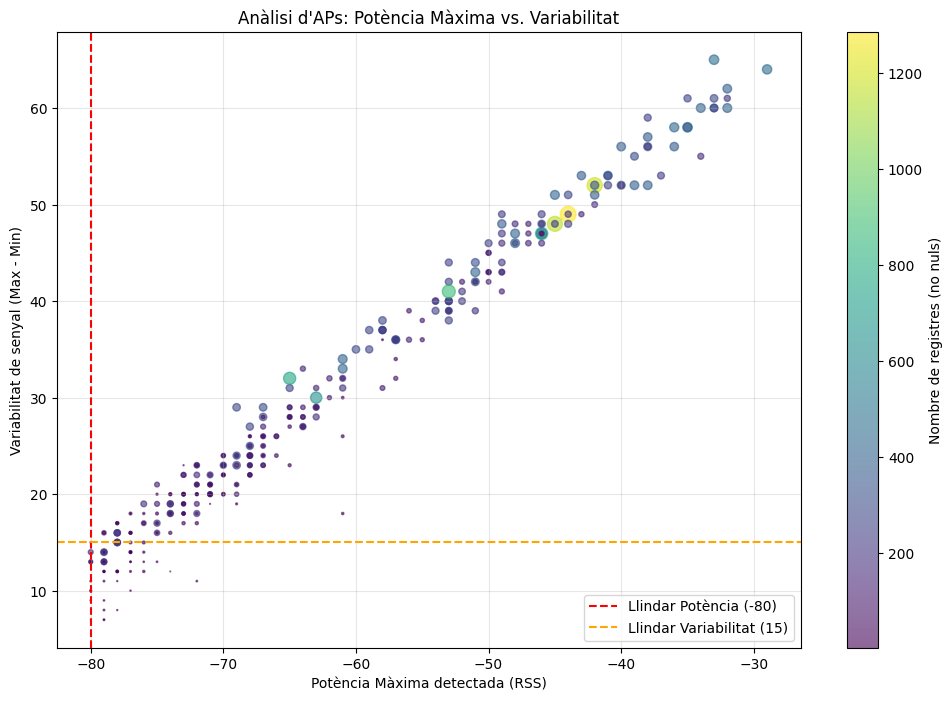

In [ ]:
# Transposar per tenir els APs a les files
df_filtre = min_max.T

# Calcular el rang (max - min)
df_filtre['rang'] = df_filtre['max'] - df_filtre['min']

# Comptar quants valors no són nulls per AP
df_filtre['comptador_non_null'] = df_train_2019_reduced_3.drop(columns='Pis').count()

# Definir els llindars
llindar_potencia_max = -80
llindar_rang = 15

# Gràfic
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    df_filtre['max'],
    df_filtre['rang'],
    c=df_filtre['comptador_non_null'],
    cmap='viridis',
    alpha=0.6,
    s=df_filtre['comptador_non_null'] / 10
)

# Afegir els llindars
plt.axvline(x=llindar_potencia_max, color='red', linestyle='--', label='Llindar Potència (-80)')
plt.axhline(y=llindar_rang, color='orange', linestyle='--', label='Llindar Variabilitat (15)')

plt.colorbar(scatter, label='Nombre de registres (no nuls)')
plt.title('Anàlisi d\'APs: Potència Màxima vs. Variabilitat')
plt.xlabel('Potència Màxima detectada (RSS)')
plt.ylabel('Variabilitat de senyal (Max - Min)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


*   **Quadrant Superior Dret:** APs amb senyal fort i molta variabilitat. Són els millors predictors.

*   **Zona Esquerra:** APs que tenen una potència màxima molt baixa. Solen ser punts de plantes llunyanes o altres edificis.

*   **Zona Inferior:** APs que tenen una baixa variabilitat. Si tenen pocs registres, són prescindibles.

*   **Color/Mida:** Com més groc i gran sigui el punt, més dades té aquell AP. Si un AP està situat a la zona "dolenta" i té molt pocs registres, és prescindible.

In [ ]:
# Aplicar el filtre
aps_bons = df_filtre[
    (df_filtre['rang'] >= llindar_rang) &
    (df_filtre['max'] > llindar_potencia_max)
].index

# Crear el DataFrame filtrat
df_train_2019_reduced_4 = df_train_2019_reduced_3[aps_bons.tolist() + ['Pis']]

print(f"Dimensions originals: {df_train_2019_reduced_3.shape[1]}")
print(f"Dimensions noves: {df_train_2019_reduced_4.shape[1]}")

Dimensions originals: 337
Dimensions noves: 290


## Experiments

A continuació, s'han elaborat una sèrie d'experiments utilitzant els models Random Forest i KNN.

### Experiment 1:

Utilitzar les dades sense tractar en el RF i KNN.

In [ ]:
# Preparar les dades
X_train = df_train_rss_2019.fillna(-105)
y_train = df_train_fl_2019.values.ravel()

X_val = df_val_rss_2019.fillna(-105)
y_val = df_val_fl_2019.values.ravel()

In [ ]:
# Random Forest
# Inicialitzar el model
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenar el model
model_rf.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_rf.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {len(X_train.columns)}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 708
Accuracy a Validació: 0.9846

Informe de Classificació:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       176
           1     1.0000    0.9800    0.9899       800
           2     0.8049    1.0000    0.8919        66

    accuracy                         0.9846      1042
   macro avg     0.9350    0.9933    0.9606      1042
weighted avg     0.9876    0.9846    0.9854      1042



In [ ]:
# KNN
# Normalització
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Inicialitzar el model
model_knn = KNeighborsClassifier(
    n_neighbors=4,
    weights='distance',
    metric='manhattan'
)

# Entrenar el model
model_knn.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_knn.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {X_train.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 708
Accuracy a Validació: 0.9770

Informe de Classificació:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       176
           1     1.0000    0.9700    0.9848       800
           2     0.7333    1.0000    0.8462        66

    accuracy                         0.9770      1042
   macro avg     0.9111    0.9900    0.9436      1042
weighted avg     0.9831    0.9770    0.9786      1042



### Experiment 2:
Conjunt reduït amb la reducció manual inicial.

In [ ]:
# Preparar les dades
columnes_finals = df_train_2019_reduced_4.drop(columns=['Pis']).columns.tolist()

X_train = df_train_rss_2019[columnes_finals].fillna(-105)
y_train = df_train_fl_2019.values.ravel()

X_val = df_val_rss_2019[columnes_finals].fillna(-105)
y_val = df_val_fl_2019.values.ravel()

In [ ]:
# Random Forest
# Inicialitzar el model
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenar el model
model_rf.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_rf.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {X_train.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 289
Accuracy a Validació: 0.9875

Informe de Classificació:
              precision    recall  f1-score   support

           0     0.9888    1.0000    0.9944       176
           1     1.0000    0.9838    0.9918       800
           2     0.8571    1.0000    0.9231        66

    accuracy                         0.9875      1042
   macro avg     0.9486    0.9946    0.9697      1042
weighted avg     0.9891    0.9875    0.9879      1042



In [ ]:
# KNN
# Normalització
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Inicialitzar el model
model_knn = KNeighborsClassifier(
    n_neighbors=4,
    weights='distance',
    metric='manhattan'
)

# Entrenar el model
model_knn.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_knn.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {X_train.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 289
Accuracy a Validació: 0.9846

Informe de Classificació:
              precision    recall  f1-score   support

           0     0.9888    1.0000    0.9944       176
           1     0.9987    0.9812    0.9899       800
           2     0.8333    0.9848    0.9028        66

    accuracy                         0.9846      1042
   macro avg     0.9403    0.9887    0.9623      1042
weighted avg     0.9866    0.9846    0.9851      1042



### Experiment 3:
Aplicar una reducció de dimensionalitat més agresiva.

In [ ]:
def aplicar_reduccio_agressiva(df, ap_cols, floor_col='Pis',
                               min_presencia=0.05,
                               min_variance=15.0,
                               top_n_per_floor=10,
                               quantile=0.75,
                               valor_nan=-105):
    """
    Aplica filtres de reducció de dimensionalitat per optimitzar el dataset d'APs.

    Paràmetres:
    - df: DataFrame original (NaN = AP no detectat).
    - ap_cols: Llista de columnes que són punts d'accés.
    - floor_col: Nom de la columna que indica la planta.
    - min_presencia: % mínim de registres on l'AP ha d'haver estat detectat (0.0 a 1.0).
    - min_variance: Llindar de variància.
    - top_n_per_floor: Número d'APs per cada planta.
    - quantile: Percentil per avaluar la representativitat de cada AP per planta (0.0 a 1.0).
    - valor_nan: Valor per substituir els NaN al DataFrame retornat.
    """

    print(f"--- Iniciant reducció: {len(ap_cols)} APs inicials ---")
    df_temp = df.copy()
    aps_actuals = list(ap_cols)

    # 1. FILTRE DE PRESÈNCIA
    # % de vegades que cada AP apareix
    presencia = df_temp[aps_actuals].notna().mean()
    # Aplicar filtre
    aps_actuals = presencia[presencia >= min_presencia].index.tolist()
    print(f"Pas 1 (Presència >= {min_presencia*100}%): Queden {len(aps_actuals)} APs")

    # 2. FILTRE DE VARIÀNCIA
    # Omplir NaN amb valor_nan per poder calcular la variància
    df_filled = df_temp[aps_actuals].fillna(valor_nan)
    # Elimina els AP amb poca variabilitat
    selector = VarianceThreshold(threshold=min_variance)
    selector.fit(df_filled)
    aps_actuals = [ap for ap, support in zip(aps_actuals, selector.get_support()) if support]
    print(f"Pas 2 (Variància >= {min_variance}): Queden {len(aps_actuals)} APs")

    # 3. FILTRE DE COBERTURA DE PLANTA
    millors_aps_per_planta = set()
    for planta in df_temp[floor_col].unique():
      # Agafar les dades de la planta
      df_planta = df_temp[df_temp[floor_col] == planta][aps_actuals]
      # Calcular el percentil per trobar les deteccions representatives
      representativitat = df_planta.quantile(quantile)
      # Eliminar APs que mai detectats en la planta
      representativitat = representativitat.dropna()
      # Agafar els més representatius
      n = min(top_n_per_floor, len(representativitat))
      top_aps = representativitat.nlargest(n).index.tolist()
      # Combinar els millors APs de les plantes
      millors_aps_per_planta.update(top_aps)

    aps_finals = list(millors_aps_per_planta)
    print(f"Pas 3 (Top {top_n_per_floor} APs per planta, percentil {quantile}): Queden {len(aps_finals)} APs totals")

    # Retornar el DataFrame amb les columnes seleccionades + llista dels APs seleccionats
    cols_no_ap = [c for c in df.columns if c not in ap_cols]
    df_resultat = df[cols_no_ap + aps_finals].copy()
    df_resultat[aps_finals] = df_resultat[aps_finals].fillna(valor_nan)

    return df_resultat, aps_finals

#### Experiment 3.1:

Reducció Moderada

In [ ]:
# Preparació de les dades
df_cons, aps_cons = aplicar_reduccio_agressiva(df_train_2019_reduced_4,
                                               df_train_2019_reduced_4.drop(columns=['Pis']).columns.tolist(),
                                               min_presencia=0.05,
                                               min_variance=15,
                                               top_n_per_floor=50)

X_train = df_train_rss_2019[aps_cons].fillna(-105)
y_train = df_train_fl_2019.values.ravel()

X_val = df_val_rss_2019[aps_cons].fillna(-105)
y_val = df_val_fl_2019.values.ravel()

--- Iniciant reducció: 289 APs inicials ---
Pas 1 (Presència >= 5.0%): Queden 117 APs
Pas 2 (Variància >= 15): Queden 117 APs
Pas 3 (Top 50 APs per planta, percentil 0.75): Queden 93 APs totals


In [ ]:
# Random Forest
# Inicialitzar el model
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenar el model
model_rf.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_rf.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {X_train.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 93
Accuracy a Validació: 0.9818

Informe de Classificació:
              precision    recall  f1-score   support

           0     0.9944    1.0000    0.9972       176
           1     0.9987    0.9775    0.9880       800
           2     0.7927    0.9848    0.8784        66

    accuracy                         0.9818      1042
   macro avg     0.9286    0.9874    0.9545      1042
weighted avg     0.9849    0.9818    0.9826      1042



In [ ]:
# KNN
# Normalització
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Inicialitzar el model
model_knn = KNeighborsClassifier(
    n_neighbors=4,
    weights='distance',
    metric='manhattan'
)

# Entrenar el model
model_knn.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_knn.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {X_train.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 93
Accuracy a Validació: 0.9741

Informe de Classificació:
              precision    recall  f1-score   support

           0     0.9942    0.9773    0.9857       176
           1     1.0000    0.9725    0.9861       800
           2     0.7143    0.9848    0.8280        66

    accuracy                         0.9741      1042
   macro avg     0.9028    0.9782    0.9333      1042
weighted avg     0.9809    0.9741    0.9760      1042



#### Experiment 3.2:

Reducció Agresiva

In [ ]:
# Preparació de les dades
df_cons, aps_cons = aplicar_reduccio_agressiva(df_train_2019_reduced_4,
                                               df_train_2019_reduced_4.drop(columns=['Pis']).columns.tolist(),
                                               min_presencia=0.10,
                                               min_variance=15,
                                               top_n_per_floor=30)

X_train = df_train_rss_2019[aps_cons].fillna(-105)
y_train = df_train_fl_2019.values.ravel()

X_val = df_val_rss_2019[aps_cons].fillna(-105)
y_val = df_val_fl_2019.values.ravel()

--- Iniciant reducció: 289 APs inicials ---
Pas 1 (Presència >= 10.0%): Queden 34 APs
Pas 2 (Variància >= 15): Queden 34 APs
Pas 3 (Top 30 APs per planta, percentil 0.75): Queden 34 APs totals


In [ ]:
# Random Forest
# Inicialitzar el model
model_rf = RandomForestClassifier(n_estimators=100, random_state=42)

# Entrenar el model
model_rf.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_rf.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {X_train.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 34
Accuracy a Validació: 0.9549

Informe de Classificació:
              precision    recall  f1-score   support

           0     0.9877    0.9148    0.9499       176
           1     0.9798    0.9688    0.9742       800
           2     0.6705    0.8939    0.7662        66

    accuracy                         0.9549      1042
   macro avg     0.8793    0.9258    0.8968      1042
weighted avg     0.9615    0.9549    0.9569      1042



In [ ]:
# KNN
# Normalització
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

# Inicialitzar el model
model_knn = KNeighborsClassifier(
    n_neighbors=4,
    weights='distance',
    metric='manhattan'
)

# Entrenar el model
model_knn.fit(X_train, y_train)

# Predir sobre el conjunt de validació
preds_val = model_knn.predict(X_val)

# Avaluar els resultats
print(f"Nombre d'APs utilitzats: {X_train.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds_val):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds_val, digits=4))

Nombre d'APs utilitzats: 34
Accuracy a Validació: 0.8647

Informe de Classificació:
              precision    recall  f1-score   support

           0     0.9758    0.9148    0.9443       176
           1     0.9826    0.8475    0.9101       800
           2     0.3316    0.9394    0.4901        66

    accuracy                         0.8647      1042
   macro avg     0.7633    0.9006    0.7815      1042
weighted avg     0.9402    0.8647    0.8892      1042



### Experiment 4:

A partir del Random Forest del primer experiment, analitzar els punts d'accés més importants que el model determina.

El RF té la propietat feature_importances_ que diu quins APs considera que són més importants.

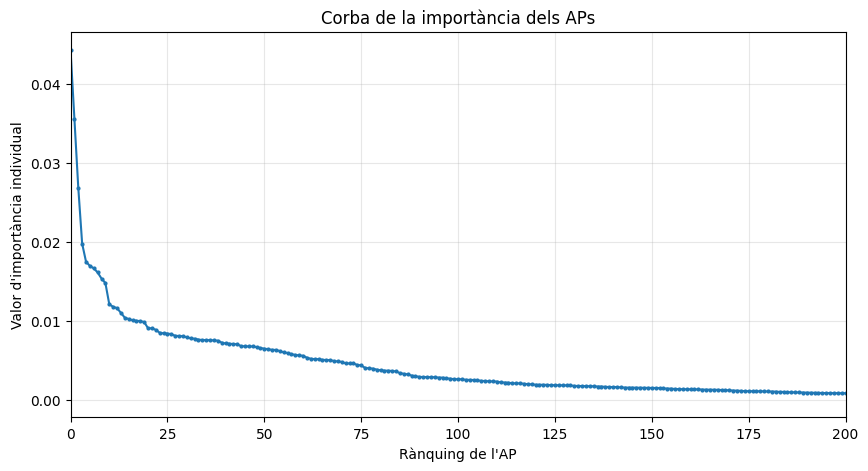

In [ ]:
# APs més importants
importances = model_rf.feature_importances_
noms_columnes = X_train.columns

# Crear un rànquing
importances_df = pd.DataFrame({'AP': noms_columnes, 'Importancia': importances})
data_sorted = importances_df.sort_values(by='Importancia', ascending=False)

# Visualitzar
plt.figure(figsize=(10, 5))
plt.plot(data_sorted['Importancia'].values, marker='o', markersize=2, linestyle='-')
plt.title('Corba de la importància dels APs')
plt.xlabel('Rànquing de l\'AP')
plt.ylabel('Valor d\'importància individual')
plt.grid(True, alpha=0.3)
plt.xlim(0, 200)
plt.show()

In [ ]:
# Preparació de les dades amb els millors APs trobats per RF
n_aps = 85
millors_aps = data_sorted.head(n_aps)['AP'].tolist()
X_train_top = X_train[millors_aps]
X_val_top = X_val[millors_aps]

In [ ]:
# Random Forest
model_rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
model_rf_final.fit(X_train_top, y_train)

# Validar
preds = model_rf_final.predict(X_val_top)

# Avaluació resultats
print(f"Nombre d'APs utilitzats: {X_train_top.shape[1]}")
print(f"Accuracy a Validació: {accuracy_score(y_val, preds):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_val, preds, digits=4))

Nombre d'APs utilitzats: 85
Accuracy a Validació: 0.9779

Informe de Classificació:
              precision    recall  f1-score   support

           0     0.9941    0.9545    0.9739       176
           1     0.9887    0.9825    0.9856       800
           2     0.8333    0.9848    0.9028        66

    accuracy                         0.9779      1042
   macro avg     0.9387    0.9740    0.9541      1042
weighted avg     0.9798    0.9779    0.9784      1042



### Avaluació final

Utilitzant el Random Forest de l'experiment 3.1

In [ ]:
# Preparació de les dades
X_test = df_test_rss_2019[aps_cons].fillna(-105)
y_test = df_test_fl_2019.iloc[:, 4].values

preds_test = model_rf.predict(X_test)
print(f"Accuracy a Test: {accuracy_score(y_test, preds_test):.4f}")
print("\nInforme de Classificació:")
print(classification_report(y_test, preds_test, digits=4))

Accuracy a Test: 1.0000

Informe de Classificació:
              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000        25
           1     1.0000    1.0000    1.0000        50
           2     1.0000    1.0000    1.0000        17

    accuracy                         1.0000        92
   macro avg     1.0000    1.0000    1.0000        92
weighted avg     1.0000    1.0000    1.0000        92

